In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

## Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [ ]:
heart_data = pd.read_csv("heart_disease.xls")
heart_data

In [3]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [4]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


In [5]:
heart_data.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [6]:
heart_data.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

In [7]:
heart_data.duplicated().sum()

np.int64(90)

## 2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.


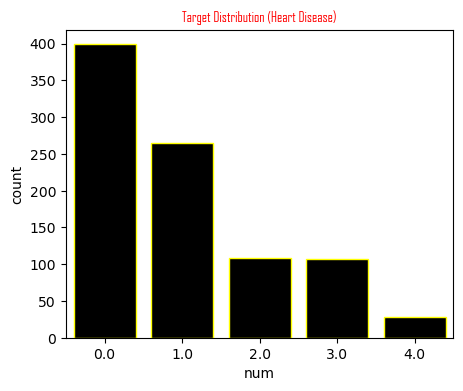

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x=heart_data['num'], color="black", edgecolor="yellow")
plt.title("Target Distribution (Heart Disease)", color="red", fontsize="16", weight="bold", style='italic', font="agency fb")
plt.show()

In [15]:
num_cols = heart_data.select_dtypes(include=[np.number]).columns

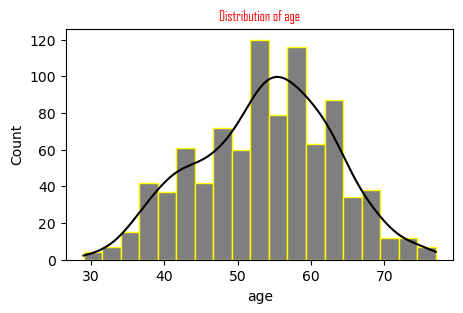

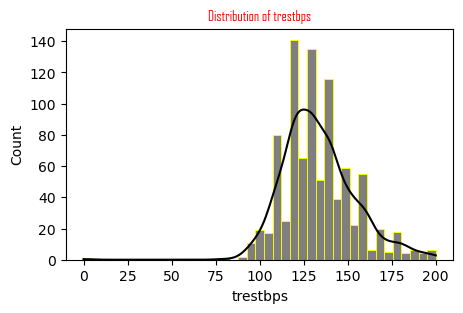

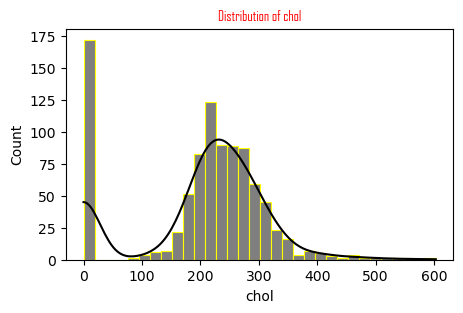

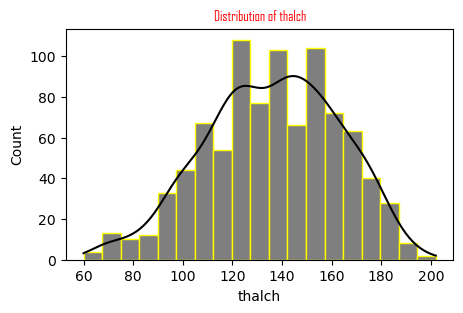

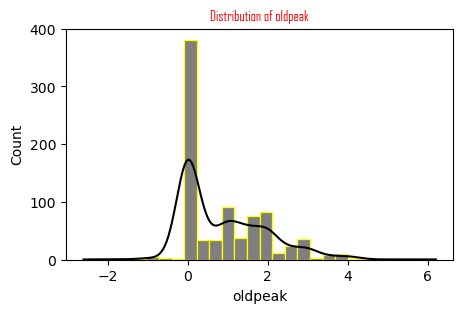

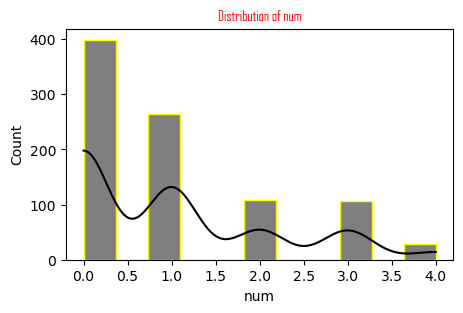

In [18]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(heart_data[col], kde=True, color="black", edgecolor="yellow")
    plt.title(f"Distribution of {col}", color="red", fontsize="16", weight="bold", style='italic', font="agency fb")
    plt.show()

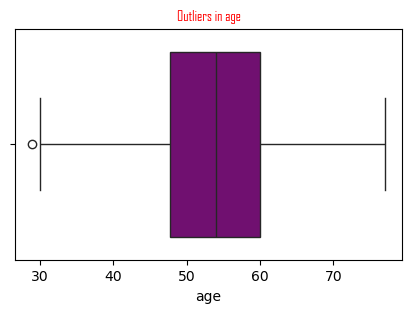

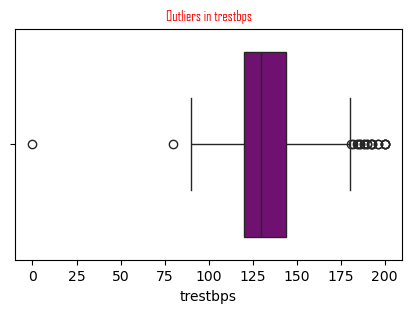

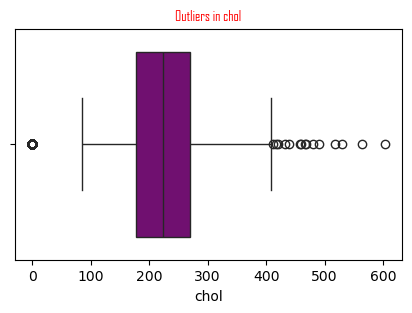

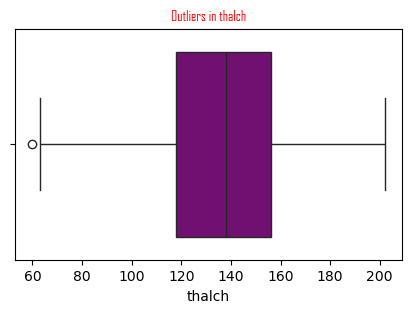

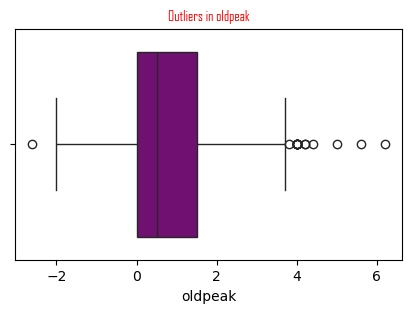

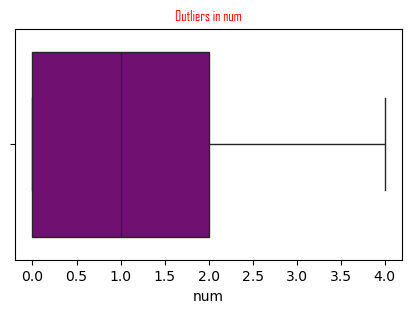

In [22]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=heart_data[col], color="purple")
    plt.title(f"Outliers in {col}", color="red", fontsize="16", weight="bold", style='italic', font="agency fb")
    plt.show()

## 3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [23]:
label_cols = ['sex','cp','restecg','slope','thal','exang','fbs']

In [24]:
for col in label_cols:
    if heart_data[col].dtype == "object":
        heart_data[col] = LabelEncoder().fit_transform(heart_data[col])

In [25]:
heart_data["target"] = (heart_data["num"] > 0).astype(int)
heart_data.drop(columns=["num"], inplace=True)

In [26]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,target
0,63.0,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,0
1,41.0,1,1,135.0,203.0,0,1,132.0,0,0.0,1,0,0
2,57.0,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,0
3,52.0,1,3,118.0,186.0,0,0,190.0,0,0.0,1,0,0
4,57.0,1,0,110.0,201.0,0,1,126.0,1,1.5,1,0,0


## 4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [27]:
X = heart_data.drop("target", axis=1)
y = heart_data["target"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
 X_train.shape

(799, 12)

In [30]:
X_test.shape

(200, 12)

In [31]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [33]:
accuracy_score(y_test, y_pred)

0.735

In [34]:
precision_score(y_test, y_pred)

0.7378640776699029

In [35]:
recall_score(y_test, y_pred)

0.7450980392156863

In [36]:
f1_score(y_test, y_pred)

0.7414634146341463

In [37]:
roc_auc_score(y_test, y_proba)

np.float64(0.7347939175670268)

In [38]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.73      0.72      0.73        98\n           1       0.74      0.75      0.74       102\n\n    accuracy                           0.73       200\n   macro avg       0.73      0.73      0.73       200\nweighted avg       0.73      0.73      0.73       200\n'

##  5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


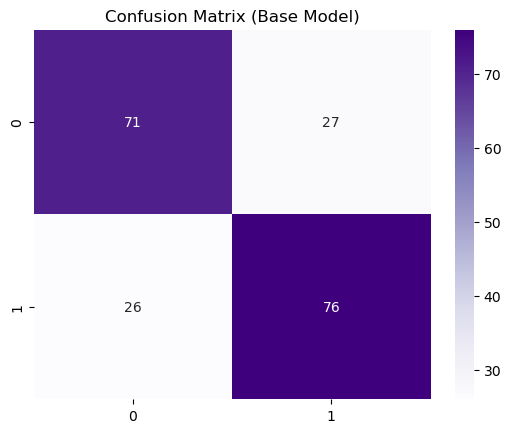

In [42]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Purples")
plt.title("Confusion Matrix (Base Model)")
plt.show()

In [43]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [44]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [45]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [46]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2}

In [47]:
best_model = grid.best_estimator_

In [48]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]

In [49]:
accuracy_score(y_test, y_pred_best)

0.76

In [50]:
precision_score(y_test, y_pred_best)

0.7872340425531915

In [51]:
recall_score(y_test, y_pred_best)

0.7254901960784313

In [52]:
f1_score(y_test, y_pred_best)

0.7551020408163265

In [53]:
roc_auc_score(y_test, y_proba_best)

np.float64(0.8296818727490998)

## 6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features


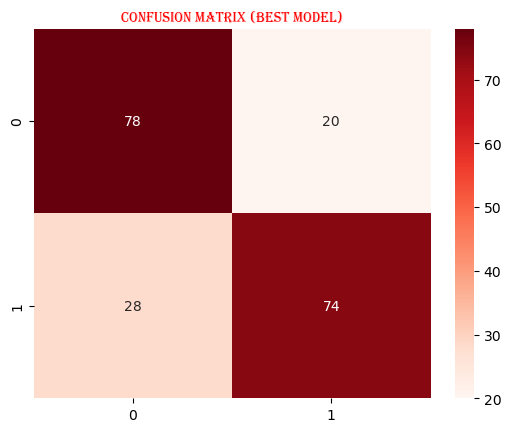

In [65]:
cm2 = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm2, annot=True, cmap="Reds")
plt.title("Confusion Matrix (Best Model)",  color="red", fontsize="16", weight="bold", style='italic', font="algerian")
plt.show()

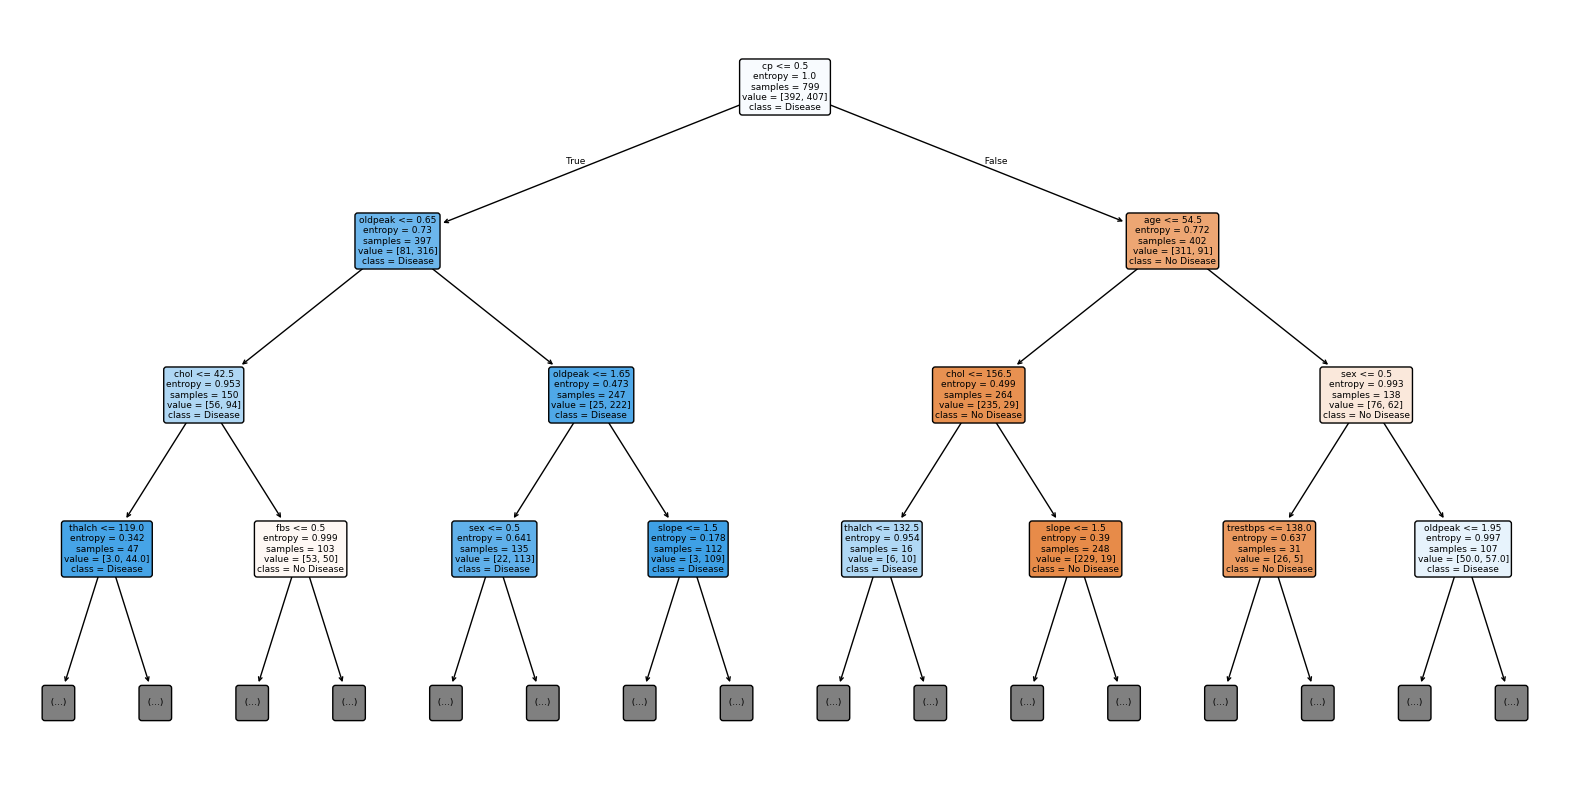

In [66]:
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    class_names=["No Disease", "Disease"],
    max_depth=3     # limit depth for readability
)
plt.show()

## Interview Questions

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


In a decision tree, hyperparameters control how the tree grows.

Some common ones are max depth, min samples split, and min samples leaf.
If the tree is allowed to grow very deep, it can overfit the data. So we limit the depth.
By increasing minimum samples for split or leaf, we make the model simpler and more stable.
The splitting criterion like Gini or Entropy decides how the best split is chosen.

#### 2. What is the difference between the Label encoding and One-hot encoding?


Label encoding converts categories into numbers in a single column, like Low = 0, Medium = 1, High = 2.
It works well when the data has a natural order.

One-hot encoding creates separate binary columns for each category, like 0 or 1.
It is better for nominal data where no order exists.

So, I use label encoding for ordinal data and one-hot encoding for nominal data to avoid misleading the model.